In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Data for Common WildAlert Targets
common_data = pd.DataFrame({
    'Variable': ['Intercept', 'C(add_outliers)[T.True]', 'C(add_trend)[T.True]', 'contamination', 'window_size'],
    'AE_coef': [13.4654, -2.4260, 0.1360, -1.3495, -0.1537],
    'AE_low': [12.974, -2.754, -0.192, -3.658, -0.184],
    'AE_high': [13.957, -2.098, 0.464, 0.959, -0.124],
    'IOF_coef': [-0.0265, 3.0230, -0.0430, 282.3723, 0.1062],
    'IOF_low': [-1.066, 2.328, -0.738, 277.484, 0.043],
    'IOF_high': [1.013, 3.718, 0.652, 287.260, 0.170]
})

# Data for Rare WildAlert Targets
rare_data = pd.DataFrame({
    'Variable': ['Intercept', 'C(add_outliers)[T.True]', 'C(add_trend)[T.True]', 'contamination', 'window_size'],
    'AE_coef': [12.4142, -3.1066, 0.0592, -0.1472, -0.1750],
    'AE_low': [11.900, -3.450, -0.284, -2.564, -0.206],
    'AE_high': [12.928, -2.763, 0.403, 2.270, -0.144],
    'IOF_coef': [2.6401, 1.7829, 0.0250, 230.1238, 0.1590],
    'IOF_low': [1.427, 0.973, -0.785, 224.422, 0.085],
    'IOF_high': [3.853, 2.593, 0.835, 235.826, 0.233]
})



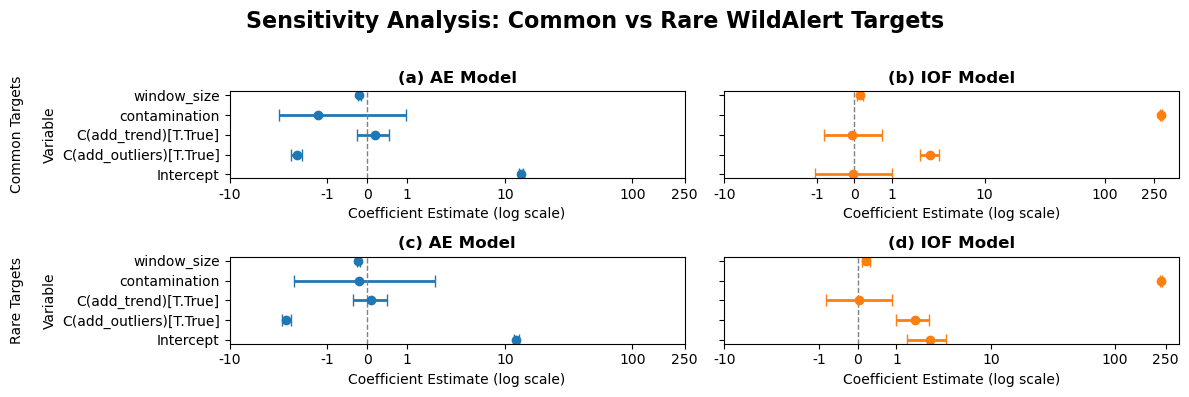

In [16]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data for Common WildAlert Targets
common_data = pd.DataFrame({
    'Variable': ['Intercept', 'C(add_outliers)[T.True]', 'C(add_trend)[T.True]', 'contamination', 'window_size'],
    'AE_coef': [13.4654, -2.4260, 0.1360, -1.3495, -0.1537],
    'AE_low': [12.974, -2.754, -0.192, -3.658, -0.184],
    'AE_high': [13.957, -2.098, 0.464, 0.959, -0.124],
    'IOF_coef': [-0.0265, 3.0230, -0.0430, 282.3723, 0.1062],
    'IOF_low': [-1.066, 2.328, -0.738, 277.484, 0.043],
    'IOF_high': [1.013, 3.718, 0.652, 287.260, 0.170]
})

# Data for Rare WildAlert Targets
rare_data = pd.DataFrame({
    'Variable': ['Intercept', 'C(add_outliers)[T.True]', 'C(add_trend)[T.True]', 'contamination', 'window_size'],
    'AE_coef': [12.4142, -3.1066, 0.0592, -0.1472, -0.1750],
    'AE_low': [11.900, -3.450, -0.284, -2.564, -0.206],
    'AE_high': [12.928, -2.763, 0.403, 2.270, -0.144],
    'IOF_coef': [2.6401, 1.7829, 0.0250, 230.1238, 0.1590],
    'IOF_low': [1.427, 0.973, -0.785, 224.422, 0.085],
    'IOF_high': [3.853, 2.593, 0.835, 235.826, 0.233]
})

# Plot setup
fig, axes = plt.subplots(2, 2, figsize=(12, 4), sharey=True)
fig.suptitle("Sensitivity Analysis: Common vs Rare WildAlert Targets", fontsize=16, fontweight='bold')

# Function to draw forest plot with log-scaled x-axis and rounded tick labels
def plot_forest_log(ax, data, model, color, label):
    coef = data[f"{model}_coef"]
    low = data[f"{model}_low"]
    high = data[f"{model}_high"]
    variables = data['Variable']

    # Signed log transform
    coef_log = np.sign(coef) * np.log1p(np.abs(coef))
    low_log = np.sign(low) * np.log1p(np.abs(low))
    high_log = np.sign(high) * np.log1p(np.abs(high))

    # Plot error bars
    ax.errorbar(coef_log, variables,
                xerr=[coef_log - low_log, high_log - coef_log],
                fmt='o', color=color, ecolor=color, elinewidth=2, capsize=4)

    ax.axvline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel("Coefficient Estimate (log scale)")
    ax.set_title(f"({label}) {model.replace('_', ' ')} Model", fontsize=12, fontweight='bold')

    # Custom tick labels using meaningful rounded values
    raw_ticks = [-10, -1, 0, 1, 10, 100, 250]
    log_ticks = [np.sign(t) * np.log1p(abs(t)) if t != 0 else 0 for t in raw_ticks]
    ax.set_xticks(log_ticks)
    ax.set_xticklabels([str(t) for t in raw_ticks])

# Common Targets
plot_forest_log(axes[0, 0], common_data, "AE", "tab:blue", "a")
plot_forest_log(axes[0, 1], common_data, "IOF", "tab:orange", "b")
axes[0, 0].set_ylabel("Common Targets\n\nVariable")

# Rare Targets
plot_forest_log(axes[1, 0], rare_data, "AE", "tab:blue", "c")
plot_forest_log(axes[1, 1], rare_data, "IOF", "tab:orange", "d")
axes[1, 0].set_ylabel("Rare Targets\n\nVariable")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('./Figure_3_final.png', dpi = 600)
plt.savefig('./Figure_3_final.svg', dpi = 600)
plt.show()
